# 비지도 학습 군집분석: 정답지가 없는 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [2]:
data = pd.read_csv("./data/shopping-data.csv")
data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


<Axes: >

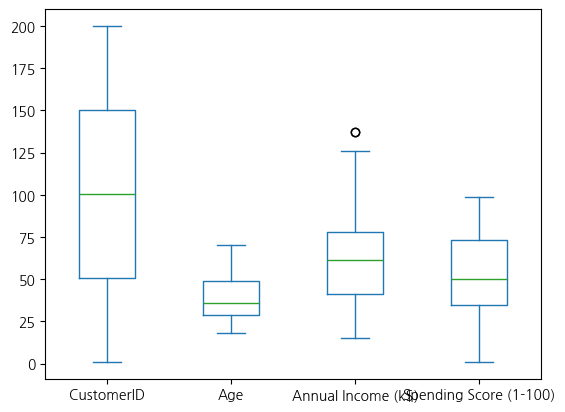

In [5]:
data.plot(kind='box')

# 군집분석(계층적 군집, 비계층적 군집)
* 계층적 군집
  * 비지도학습
  * 데이터가 적을 때 사용
  * 거리 계산 지표: 유클리드, 맨하탄, 코사인 유사도
* 계층적 군집 5가지
  * 단일연결법(single linkage), 최단연결법: 군집과 군집 사이에서 가장 가까운 데이터를 기준으로 묶음
  * 완전연결법(complite linkage), 최장연결법: 군집과 군집 사이에서 가장 먼 데이터를 기준으로 묶음
  * 평균연결법(average linkage): 군집과 군집 사이의 모든 데이터의 평균 데이터로 계산(이상치에 덜 민감)
  * 중심연결법(centroid linkage): 군집과 중심점 사이의 거리를 거리로 측정한 방법, 계산이 빠름
  * 와드연결법(ward linkage): 군집내 오차가 최소가 되는 데이터로 계산, 군집내 분산이 최소, 조밀한 군집
* 계층적 군집의 시각화는 덴드로그램으로 한다.

In [6]:
import scipy.cluster.hierarchy as shc

In [8]:
data = pd.get_dummies(data, drop_first=True)
data

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False
...,...,...,...,...,...
195,196,35,120,79,False
196,197,45,126,28,False
197,198,32,126,74,True
198,199,32,137,18,True


In [9]:
data2 = data.copy()

In [11]:
data = data.drop('CustomerID', axis=1)
data

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False
...,...,...,...,...
195,35,120,79,False
196,45,126,28,False
197,32,126,74,True
198,32,137,18,True


# 군집분석 거리가 중요하므로 스케일링 필수

In [12]:
from sklearn.preprocessing import StandardScaler

In [14]:
ss = StandardScaler()
scaled_df = ss.fit_transform(data)
scaled_df = pd.DataFrame(scaled_df, index=data.index, columns=data.columns)
scaled_df

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405
...,...,...,...,...
195,-0.276302,2.268791,1.118061,-0.886405
196,0.441365,2.497807,-0.861839,-0.886405
197,-0.491602,2.497807,0.923953,1.128152
198,-0.491602,2.917671,-1.250054,1.128152


* 싱글링키지(single linkage) 최단연결법

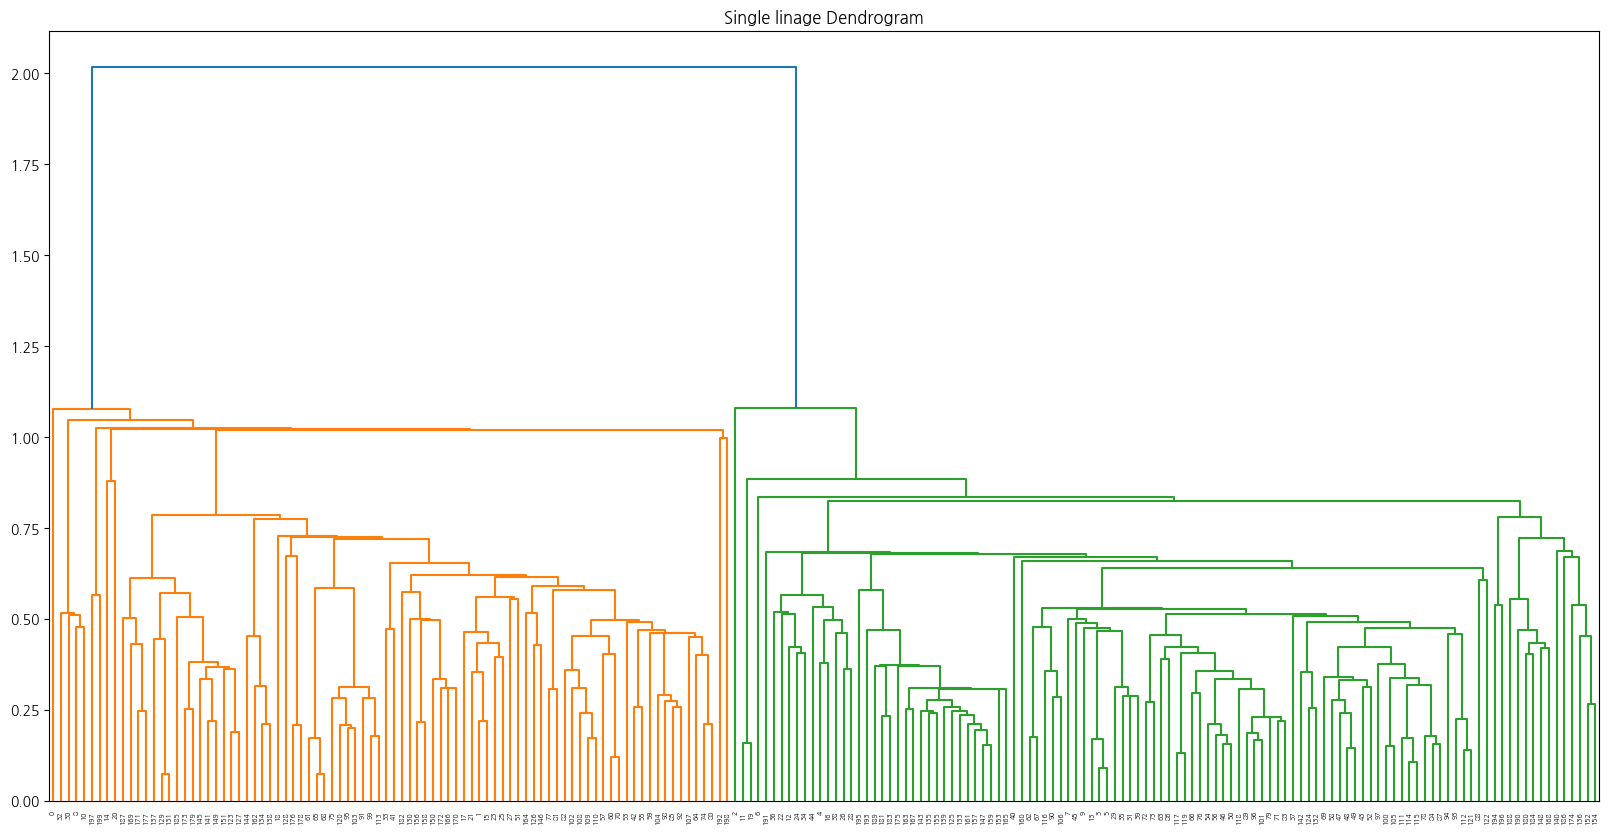

In [15]:
plt.figure(figsize=(20, 10))
plt.title('Single linage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='single'))
plt.show()

* 완전연결법(complete linkage) 최장연결법

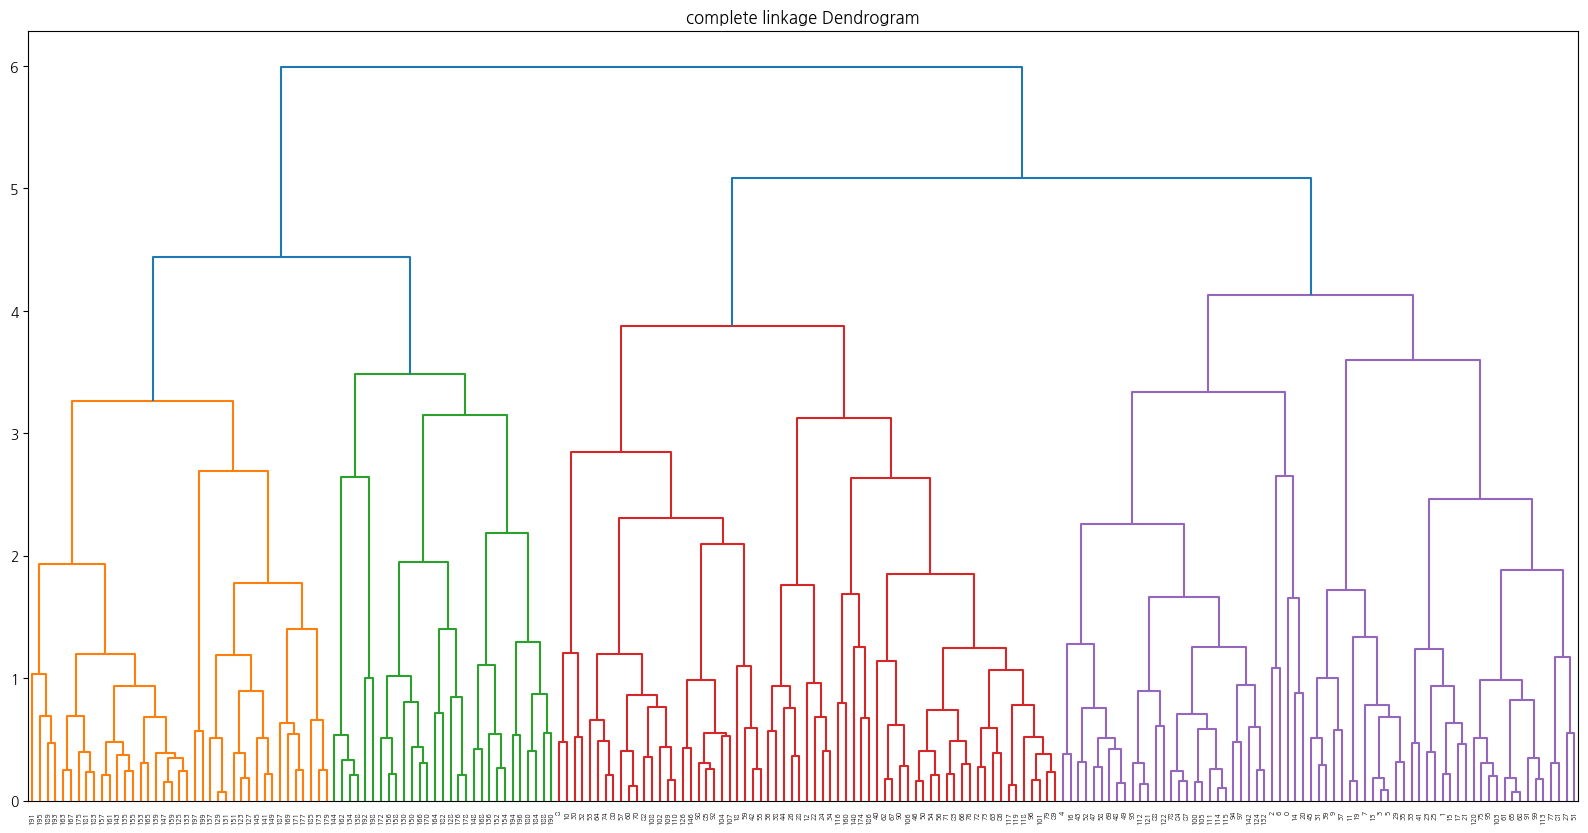

In [16]:
plt.figure(figsize=(20, 10))
plt.title('complete linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='complete'))
plt.show()

* 평균 연결법(average linkage)

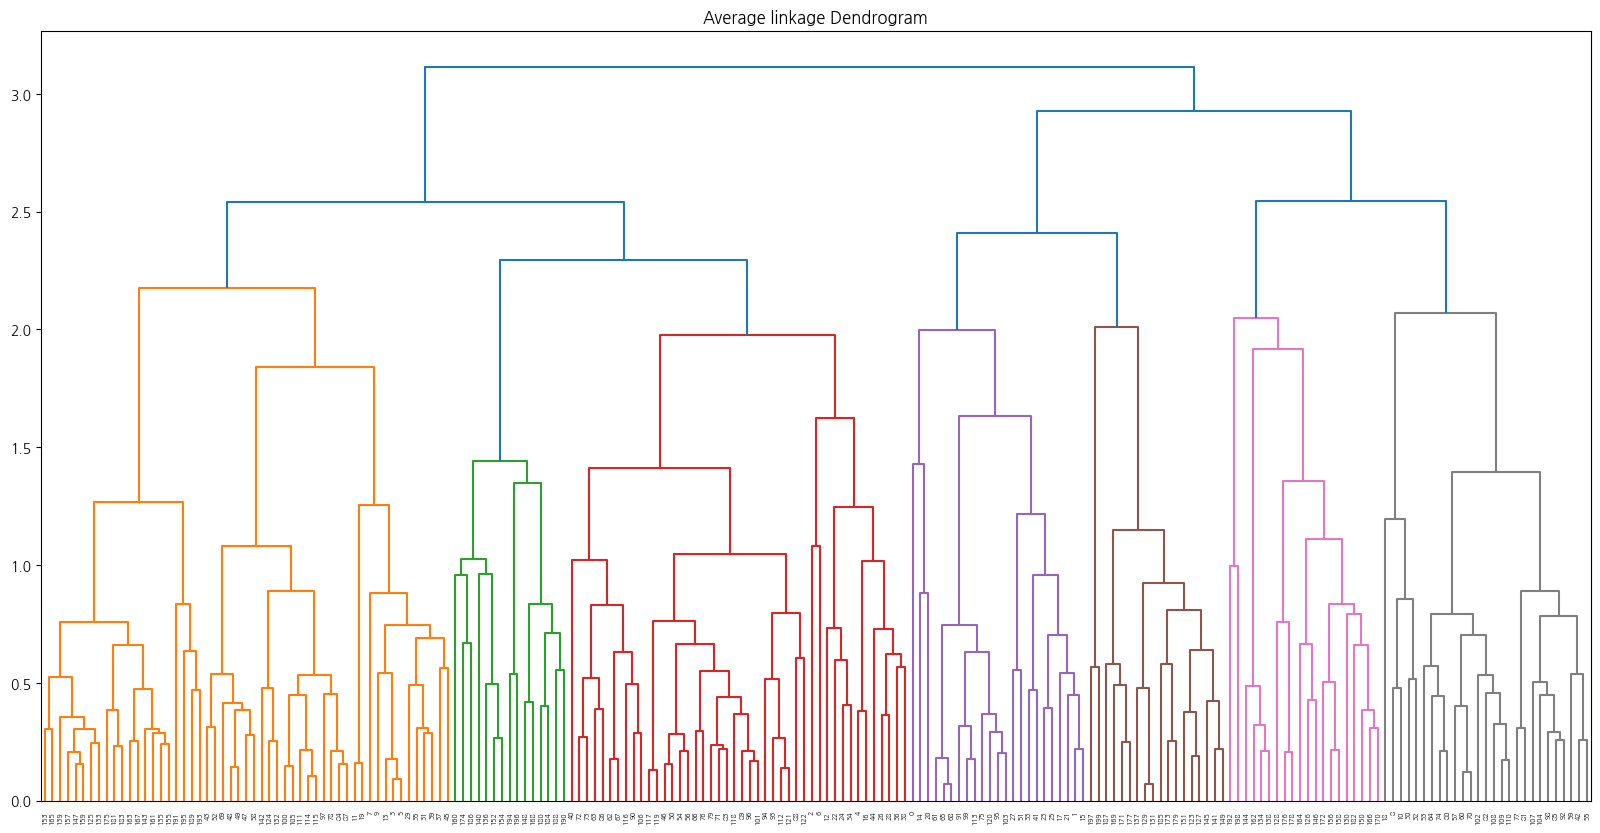

In [17]:
plt.figure(figsize=(20, 10))
plt.title('Average linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='average'))
plt.show()

* 중심연결법(centroid linkage)

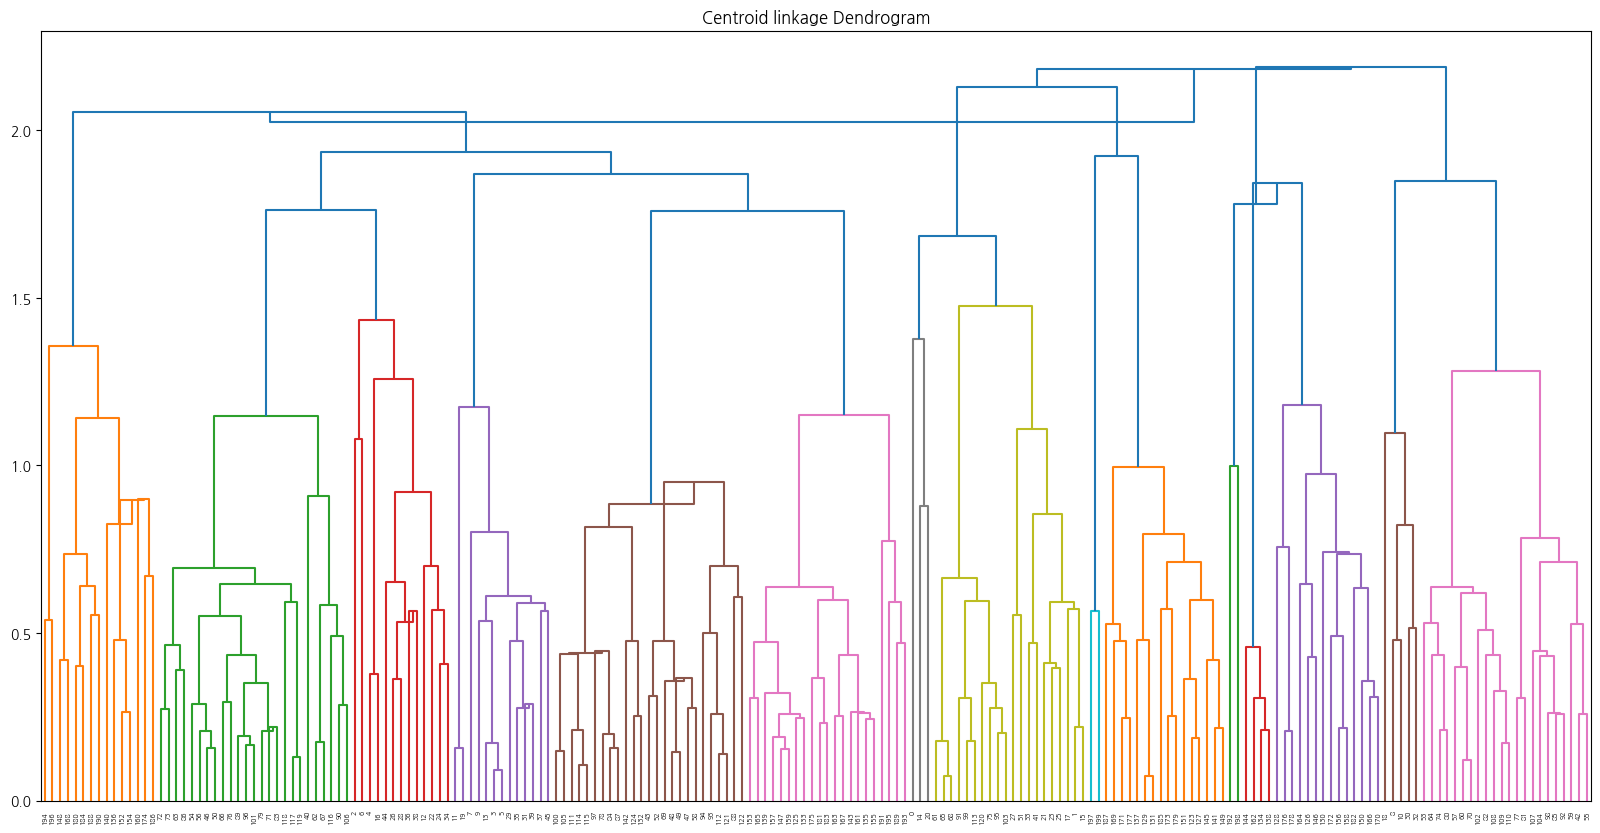

In [18]:
plt.figure(figsize=(20, 10))
plt.title('Centroid linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='centroid'))
plt.show()

* 와드연결법(ward linkage) - 군집내 분산 최소화

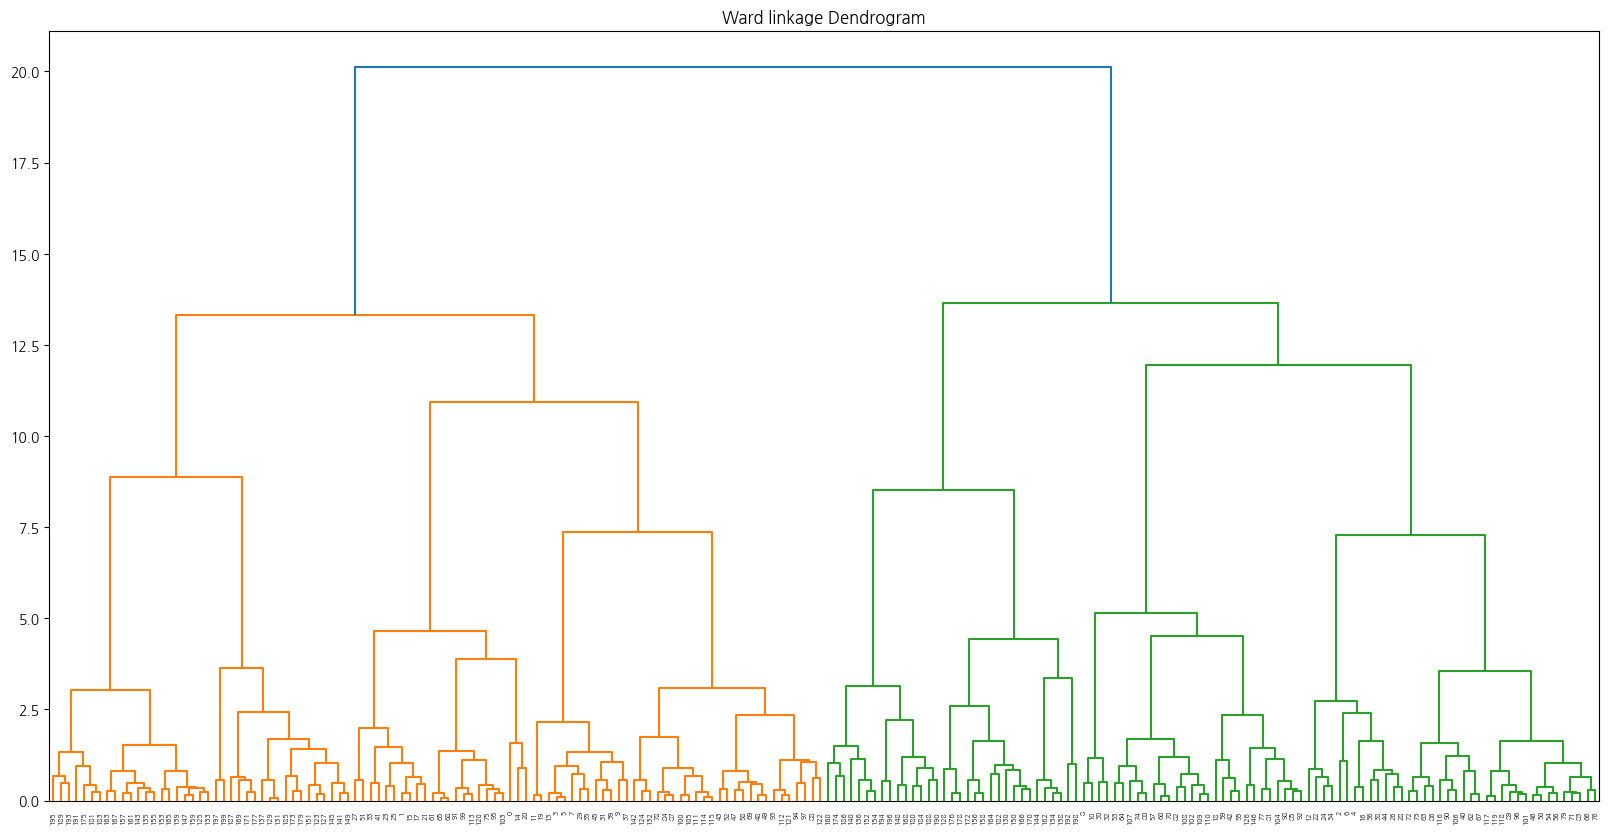

In [19]:
plt.figure(figsize=(20, 10))
plt.title('Ward linkage Dendrogram')
dend = shc.dendrogram(shc.linkage(scaled_df, method='ward'))
plt.show()

# scikit-learn을 이용한 계층군집

In [20]:
from sklearn.cluster import AgglomerativeClustering

In [21]:
single = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='single')
result = single.fit_predict(scaled_df)
result

array([0, 0, 1, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 0, 0, 2, 0, 0,
       2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 2, 2, 0, 0,
       2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 0, 0, 2, 2, 0, 0, 0,
       0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0,
       2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 0, 0, 2, 2,
       2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 2,
       0, 0, 0, 0, 2, 2, 0, 2, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0,
       0, 0])

In [22]:
data2['single'] = result
data2

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single
0,1,19,15,39,True,0
1,2,21,15,81,True,0
2,3,20,16,6,False,1
3,4,23,16,77,False,2
4,5,31,17,40,False,2
...,...,...,...,...,...,...
195,196,35,120,79,False,2
196,197,45,126,28,False,2
197,198,32,126,74,True,0
198,199,32,137,18,True,0


In [24]:
for linkage in ['complete', 'average', 'ward']:
    single = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage=linkage)
    result = single.fit_predict(scaled_df)
    data2[linkage] = result
    display(data2)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,complete
0,1,19,15,39,True,0,1
1,2,21,15,81,True,0,1
2,3,20,16,6,False,1,1
3,4,23,16,77,False,2,1
4,5,31,17,40,False,2,1
...,...,...,...,...,...,...,...
195,196,35,120,79,False,2,0
196,197,45,126,28,False,2,0
197,198,32,126,74,True,0,0
198,199,32,137,18,True,0,0


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,complete,average
0,1,19,15,39,True,0,1,2
1,2,21,15,81,True,0,1,2
2,3,20,16,6,False,1,1,1
3,4,23,16,77,False,2,1,1
4,5,31,17,40,False,2,1,1
...,...,...,...,...,...,...,...,...
195,196,35,120,79,False,2,0,1
196,197,45,126,28,False,2,0,1
197,198,32,126,74,True,0,0,2
198,199,32,137,18,True,0,0,0


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,complete,average,ward
0,1,19,15,39,True,0,1,2,0
1,2,21,15,81,True,0,1,2,0
2,3,20,16,6,False,1,1,1,1
3,4,23,16,77,False,2,1,1,0
4,5,31,17,40,False,2,1,1,1
...,...,...,...,...,...,...,...,...,...
195,196,35,120,79,False,2,0,1,0
196,197,45,126,28,False,2,0,1,2
197,198,32,126,74,True,0,0,2,0
198,199,32,137,18,True,0,0,0,2


In [25]:
data2

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,single,complete,average,ward
0,1,19,15,39,True,0,1,2,0
1,2,21,15,81,True,0,1,2,0
2,3,20,16,6,False,1,1,1,1
3,4,23,16,77,False,2,1,1,0
4,5,31,17,40,False,2,1,1,1
...,...,...,...,...,...,...,...,...,...
195,196,35,120,79,False,2,0,1,0
196,197,45,126,28,False,2,0,1,2
197,198,32,126,74,True,0,0,2,0
198,199,32,137,18,True,0,0,0,2
